# Sprint 17 — Protocole UART & Périphériques HAL

**Projet** : CL-Embedded — Apprentissage Incrémental pour Systèmes Embarqués  
**Board** : NUCLEO-F439ZI (Cortex-M4 @ 180 MHz, 256 Ko SRAM)  
**Auteur** : Léonard Rivals | ISAE-SUPAERO × ENAC × Edge Spectrum  
**Sprint** : 17 — Périphériques HAL (GPIO, UART, DWT, PWM), protocole UART v2, Renode CI

Pas encore d'expérience board complète — ce notebook visualise l'architecture du protocole,  
les timings DWT et les mappings périphériques définis en Sprint 17.

In [1]:
import json, numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patches as FancyBboxPatch
from matplotlib.patches import FancyArrowPatch
from pathlib import Path

FIG_DIR = Path("../experiments/figures/sprint17")
FIG_DIR.mkdir(parents=True, exist_ok=True)

PALETTE = {
    "EWC":         "#42A5F5",
    "HDC":         "#AB47BC",
    "TinyOL":      "#EF5350",
    "Mahalanobis": "#66BB6A",
    "request":     "#1565C0",
    "response":    "#E65100",
    "control":     "#2E7D32",
    "header":      "#37474F",
}
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})
print("Sprint 17 — Protocole UART & Périphériques HAL")

Sprint 17 — Protocole UART & Périphériques HAL


---
## 0. Protocole UART — Étapes de communication MCU

Le pipeline d'inférence embarqué suit 6 étapes séquentielles à chaque cycle de 32 octets reçus.

### Étape 1 — Réception de la trame
Le MCU reçoit une trame de 32 octets via USART3 (115 200 baud, 8N1).
Interruption `HAL_UART_RxCpltCallback` → buffer circulaire DMA.

### Étape 2 — Décodage des features
Extraction des N features `float32` depuis les octets 4–(4+4N−1) de la trame.
Validation CRC8 sur les 31 premiers octets avant décodage.

### Étape 3 — Sélection du modèle et inférence
Selon le byte CMD (`0x01`=Mahalanobis, `0x02`=EWC, `0x03`=TinyOL) :
appel de la fonction d'inférence correspondante. Chronométrage via DWT CYCCNT.

### Étape 4 — Mise à jour des métriques en ligne
Mise à jour des compteurs `online_metrics` : accuracy glissante, throughput, forgetting estimé.
Optionnel selon flag `UPDATE` dans CMD.

### Étape 5 — Encodage et envoi de la réponse
Construction de la trame réponse v2 (14 octets) ou v3 (21 octets).
Envoi DMA via `HAL_UART_Transmit_DMA`.

### Étape 6 — Contrôle LED
LED verte (LD1) : inférence OK. LED rouge (LD3) : erreur CRC ou overflow.
Toggle LED bleue (LD2) à chaque cycle pour watchdog visuel.

In [ ]:
# ── Diagramme de séquence UART — PC ↔ MCU (6 étapes) ──
fig, ax = plt.subplots(figsize=(13, 9))
ax.set_xlim(0, 12)
ax.set_ylim(-0.5, 10.5)
ax.axis("off")
ax.set_title("Sprint 17 — Protocole UART : Diagramme de séquence PC ↔ MCU\n"
             "(6 étapes séquentielles par cycle de 32 octets reçus)",
             fontsize=13, fontweight="bold", pad=12)

PC_X   = 1.4
MCU_X  = 10.8
BOX_L  = 4.8
BOX_W  = 6.0

# ── Boîtes acteurs (header) ──
for cx, label, sublabel, color in [
    (PC_X,  "PC",  "sensor_stream.py",         "#37474F"),
    (MCU_X, "MCU", "NUCLEO-F439ZI  Cortex-M4", "#1565C0"),
]:
    hw = 1.15
    rect = mpatches.FancyBboxPatch((cx - hw, 9.45), hw * 2, 0.85,
                                   boxstyle="round,pad=0.08",
                                   facecolor=color, edgecolor="white", linewidth=1.8)
    ax.add_patch(rect)
    ax.text(cx, 9.75, label,    ha="center", va="center", fontsize=12,
            fontweight="bold", color="white")
    ax.text(cx, 9.5,  sublabel, ha="center", va="center", fontsize=7.5,
            color="#B0CFE8")

# ── Lignes de vie (tirets) ──
ax.plot([PC_X,  PC_X],  [9.45, 0.2], color="#90A4AE", lw=1.5, ls="--", zorder=0)
ax.plot([MCU_X, MCU_X], [9.45, 0.2], color="#90A4AE", lw=1.5, ls="--", zorder=0)

# ── Flèche requête PC → MCU ──
REQ_Y = 8.9
ax.annotate("", xy=(MCU_X - 0.08, REQ_Y), xytext=(PC_X + 0.08, REQ_Y),
            arrowprops=dict(arrowstyle="-|>", color=PALETTE["request"],
                            lw=2.5, mutation_scale=18))
ax.text((PC_X + MCU_X) / 2, REQ_Y + 0.13,
        "Trame Request — 32 octets",
        ha="center", va="bottom", fontsize=10, fontweight="bold",
        color=PALETTE["request"])
ax.text((PC_X + MCU_X) / 2, REQ_Y - 0.06,
        "USART3 · 115 200 baud · 8N1",
        ha="center", va="top", fontsize=8.5, color="#607D8B")

# ── 6 étapes MCU ──
STEPS = [
    ("1", "Réception de la trame",
     "HAL_UART_RxCpltCallback  →  buffer circulaire DMA",
     "#1976D2"),
    ("2", "Décodage des features",
     "Validation CRC8  |  N × float32  (octets 4 – 4+4N−1)",
     "#1565C0"),
    ("3", "Sélection modèle & inférence",
     "CMD 0x01=Mahal · 0x02=EWC · 0x03=TinyOL  |  chronométrage DWT CYCCNT",
     "#0D47A1"),
    ("4", "Mise à jour métriques en ligne",
     "accuracy glissante · throughput · forgetting estimé  (si flag UPDATE)",
     "#283593"),
    ("5", "Encodage & envoi de la réponse",
     "Construction trame v2 (14 B) ou v3 (21 B)  |  HAL_UART_Transmit_DMA",
     "#1A237E"),
    ("6", "Contrôle LED",
     "LD1 vert=OK · LD3 rouge=erreur CRC/overflow · LD2 toggle=watchdog",
     "#311B92"),
]

SH   = 0.70
SGAP = 0.18
S0_Y = 8.15

for i, (num, title, desc, bg) in enumerate(STEPS):
    cy = S0_Y - i * (SH + SGAP)

    rect = mpatches.FancyBboxPatch((BOX_L, cy - SH / 2), BOX_W, SH,
                                   boxstyle="round,pad=0.07",
                                   facecolor=bg, alpha=0.92,
                                   edgecolor="white", linewidth=1.2, zorder=3)
    ax.add_patch(rect)

    # Badge numéro
    circ = plt.Circle((BOX_L + 0.33, cy), 0.22, color="white", zorder=5)
    ax.add_patch(circ)
    ax.text(BOX_L + 0.33, cy, num, ha="center", va="center",
            fontsize=10, fontweight="bold", color=bg, zorder=6)

    ax.text(BOX_L + 0.68, cy + 0.12, title,
            ha="left", va="center", fontsize=9.5, fontweight="bold",
            color="white", zorder=4)
    ax.text(BOX_L + 0.68, cy - 0.14, desc,
            ha="left", va="center", fontsize=7.8, color="#B3E5FC", zorder=4)

    # Flèche inter-étapes sur la lifeline MCU
    if i < len(STEPS) - 1:
        next_cy = S0_Y - (i + 1) * (SH + SGAP)
        ax.annotate("", xy=(MCU_X, next_cy + SH / 2 + 0.03),
                    xytext=(MCU_X, cy - SH / 2 - 0.03),
                    arrowprops=dict(arrowstyle="-|>", color="#90CAF9",
                                    lw=1.3, mutation_scale=9), zorder=2)

# ── Flèche réponse MCU → PC ──
last_cy = S0_Y - (len(STEPS) - 1) * (SH + SGAP)
RESP_Y  = last_cy - SH / 2 - 0.42

ax.annotate("", xy=(PC_X + 0.08, RESP_Y), xytext=(MCU_X - 0.08, RESP_Y),
            arrowprops=dict(arrowstyle="-|>", color=PALETTE["response"],
                            lw=2.5, mutation_scale=18))
ax.text((PC_X + MCU_X) / 2, RESP_Y + 0.13,
        "Trame Réponse — 14 B (v2) / 21 B (v3)",
        ha="center", va="bottom", fontsize=10, fontweight="bold",
        color=PALETTE["response"])
ax.text((PC_X + MCU_X) / 2, RESP_Y - 0.06,
        "HAL_UART_Transmit_DMA",
        ha="center", va="top", fontsize=8.5, color="#607D8B")

plt.tight_layout()
plt.savefig(FIG_DIR / "00_uart_protocol_sequence.png", bbox_inches="tight")
plt.show()
print("Diagramme de séquence UART sauvegardé → 00_uart_protocol_sequence.png")

---
## 1. Anatomie de la trame UART v2 — Request & Response
Protocole binaire little-endian avec CRC8. Request 32 B → Response 14 B (v2) / 21 B (v3).

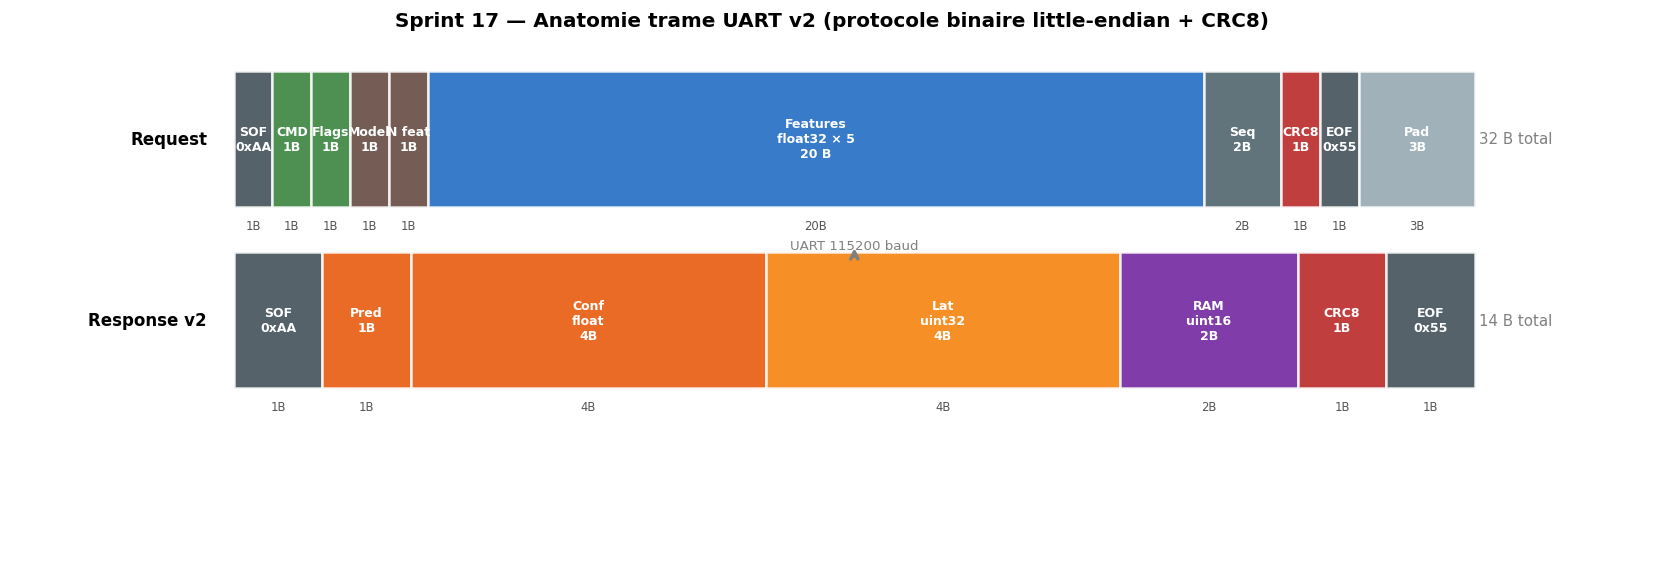

In [2]:
# ── Request frame (32 bytes) ──
req_fields = [
    ("SOF\n0xAA",       1, "#37474F"),
    ("CMD\n1B",          1, PALETTE["control"]),
    ("Flags\n1B",        1, PALETTE["control"]),
    ("Model\n1B",        1, "#5D4037"),
    ("N feat\n1B",       1, "#5D4037"),
    ("Features\nfloat32 × 5\n20 B", 20, PALETTE["request"]),
    ("Seq\n2B",          2, "#455A64"),
    ("CRC8\n1B",         1, "#B71C1C"),
    ("EOF\n0x55",        1, "#37474F"),
    ("Pad\n3B",          3, "#90A4AE"),
]
# ── Response v2 (14 bytes) ──
res_fields_v2 = [
    ("SOF\n0xAA",   1, "#37474F"),
    ("Pred\n1B",    1, PALETTE["response"]),
    ("Conf\nfloat\n4B", 4, PALETTE["response"]),
    ("Lat\nuint32\n4B",  4, "#F57C00"),
    ("RAM\nuint16\n2B",  2, "#6A1B9A"),
    ("CRC8\n1B",    1, "#B71C1C"),
    ("EOF\n0x55",   1, "#37474F"),
]

def draw_frame(ax, fields, y, height, title):
    x = 0
    total = sum(f[1] for f in fields)
    scale = 14.0 / total
    for label, size, color in fields:
        w = size * scale
        rect = plt.Rectangle((x, y), w, height, facecolor=color, alpha=0.85,
                              edgecolor="white", linewidth=1.5)
        ax.add_patch(rect)
        ax.text(x + w / 2, y + height / 2, label,
                ha="center", va="center", fontsize=7.5, color="white",
                fontweight="bold", wrap=True)
        ax.text(x + w / 2, y - 0.08, f"{size}B",
                ha="center", va="top", fontsize=7, color="#555")
        x += w
    ax.text(-0.3, y + height / 2, title, ha="right", va="center",
            fontsize=10, fontweight="bold")
    ax.text(x + 0.05, y + height / 2, f"{total} B total",
            ha="left", va="center", fontsize=9, color="gray")

fig, ax = plt.subplots(figsize=(14, 5))
ax.set_xlim(-2.5, 16)
ax.set_ylim(-0.4, 3.2)
ax.axis("off")

draw_frame(ax, req_fields,    2.0, 0.9, "Request")
draw_frame(ax, res_fields_v2, 0.8, 0.9, "Response v2")

ax.annotate("", xy=(7, 1.75), xytext=(7, 1.65),
            arrowprops=dict(arrowstyle="->", color="gray", lw=2))
ax.text(7, 1.72, "UART 115200 baud", ha="center", fontsize=8, color="gray")
ax.set_title("Sprint 17 — Anatomie trame UART v2 (protocole binaire little-endian + CRC8)",
             fontsize=12, fontweight="bold", y=0.98)

plt.tight_layout()
plt.savefig(FIG_DIR / "01_uart_frame.png", bbox_inches="tight")
plt.show()

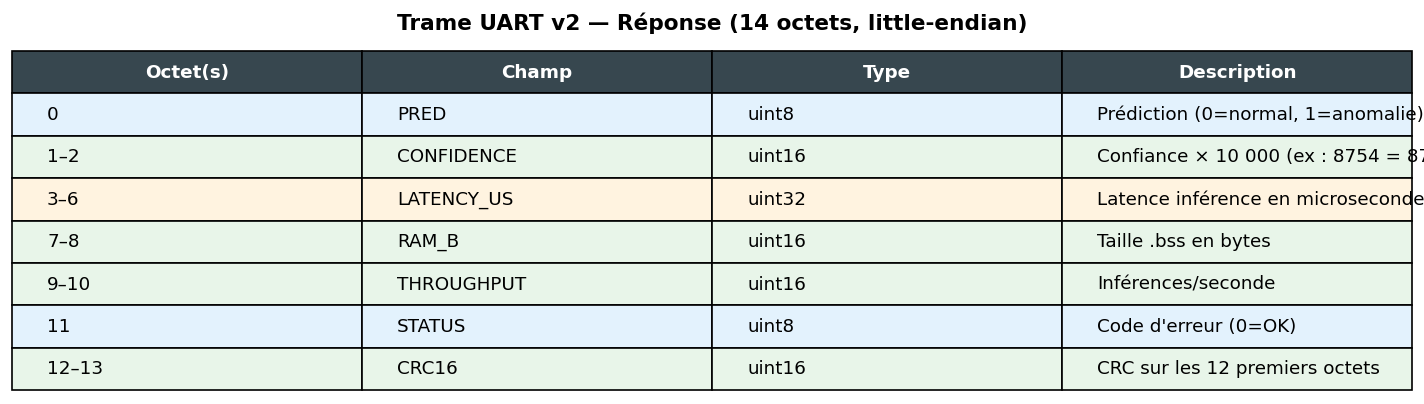

Trame v2 : 7 champs payload | 14 octets total


In [3]:
# Trame UART v2 — description tabulaire des champs de la réponse (14 octets)
v2_fields = [
    ["0",     "PRED",       "uint8",  "Prédiction (0=normal, 1=anomalie)"],
    ["1–2",   "CONFIDENCE", "uint16", "Confiance × 10 000 (ex : 8754 = 87.54 %)"],
    ["3–6",   "LATENCY_US", "uint32", "Latence inférence en microsecondes"],
    ["7–8",   "RAM_B",      "uint16", "Taille .bss en bytes"],
    ["9–10",  "THROUGHPUT", "uint16", "Inférences/seconde"],
    ["11",    "STATUS",     "uint8",  "Code d'erreur (0=OK)"],
    ["12–13", "CRC16",      "uint16", "CRC sur les 12 premiers octets"],
]
col_labels = ["Octet(s)", "Champ", "Type", "Description"]

type_bg = {"uint8": "#E3F2FD", "uint16": "#E8F5E9", "uint32": "#FFF3E0"}
cell_colors = [[type_bg.get(row[2], "#F5F5F5")] * 4 for row in v2_fields]

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.axis("off")
tbl = ax.table(cellText=v2_fields, colLabels=col_labels,
               cellColours=cell_colors, loc="center", cellLoc="left")
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1, 2.0)
for col_idx in range(4):
    tbl[(0, col_idx)].set_facecolor("#37474F")
    tbl[(0, col_idx)].set_text_props(color="white", fontweight="bold")
ax.set_title("Trame UART v2 — Réponse (14 octets, little-endian)",
             fontweight="bold", fontsize=13, pad=12)
plt.tight_layout()
plt.savefig(FIG_DIR / "01b_trame_v2_table.png", bbox_inches="tight")
plt.show()
print("Trame v2 : 7 champs payload | 14 octets total")

---
## 2. Évolution du Protocole — v1 → v2 → v3
Chaque version du protocole UART ajoute des métriques CL temps réel à la réponse.

/tmp/ipykernel_39835/2136518653.py:83: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(FIG_DIR / "02_protocol_evolution.png", bbox_inches="tight")
/tmp/ipykernel_39835/2136518653.py:83: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(FIG_DIR / "02_protocol_evolution.png", bbox_inches="tight")
/home/leonard/Documents/ENAC/cl-embedded/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/leonard/Documents/ENAC/cl-embedded/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


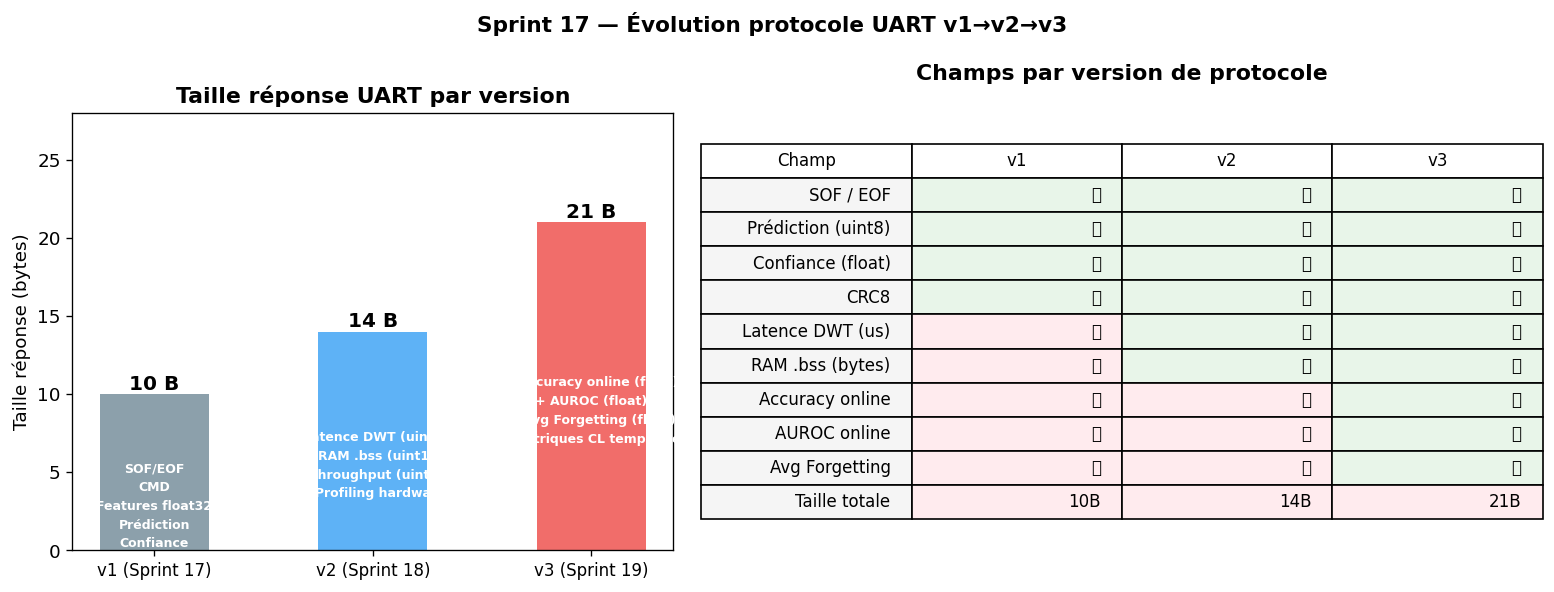

In [4]:
versions = [
    {
        "name": "v1 (Sprint 17)",
        "sprint": 17,
        "req_bytes": 32,
        "res_bytes": 10,
        "features": ["SOF/EOF", "CMD", "Features float32", "Prédiction",
                     "Confiance", "CRC8"],
        "color": "#78909C",
    },
    {
        "name": "v2 (Sprint 18)",
        "sprint": 18,
        "req_bytes": 32,
        "res_bytes": 14,
        "features": ["+ Latence DWT (uint32)", "+ RAM .bss (uint16)",
                     "+ Throughput (uint16)", "→ Profiling hardware"],
        "color": "#42A5F5",
    },
    {
        "name": "v3 (Sprint 19)",
        "sprint": 19,
        "req_bytes": 32,
        "res_bytes": 21,
        "features": ["+ Accuracy online (float)", "+ AUROC (float)",
                     "+ Avg Forgetting (float)", "→ Métriques CL temps réel"],
        "color": "#EF5350",
    },
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# — Timeline —
ax = axes[0]
sprints = [v["sprint"] for v in versions]
res_sizes = [v["res_bytes"] for v in versions]
bar_colors = [v["color"] for v in versions]

bars = ax.bar(range(len(versions)), res_sizes, color=bar_colors, width=0.5, alpha=0.85)
for i, (bar, v) in enumerate(zip(bars, versions)):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f"{v['res_bytes']} B", ha="center", fontsize=12, fontweight="bold")
    for k, feat in enumerate(v["features"]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() / 2 - k * 1.2,
                feat, ha="center", fontsize=7.5, color="white", fontweight="bold")

ax.set_xticks(range(len(versions)))
ax.set_xticklabels([v["name"] for v in versions], fontsize=10)
ax.set_ylabel("Taille réponse (bytes)")
ax.set_title("Taille réponse UART par version", fontweight="bold")
ax.set_ylim(0, 28)

# — Feature table —
ax = axes[1]
ax.axis("off")
table_data = [
    ["Champ",              "v1",  "v2",  "v3"],
    ["SOF / EOF",          "✅",  "✅",  "✅"],
    ["Prédiction (uint8)", "✅",  "✅",  "✅"],
    ["Confiance (float)",  "✅",  "✅",  "✅"],
    ["CRC8",               "✅",  "✅",  "✅"],
    ["Latence DWT (us)",   "❌",  "✅",  "✅"],
    ["RAM .bss (bytes)",   "❌",  "✅",  "✅"],
    ["Accuracy online",    "❌",  "❌",  "✅"],
    ["AUROC online",       "❌",  "❌",  "✅"],
    ["Avg Forgetting",     "❌",  "❌",  "✅"],
    ["Taille totale",      "10B", "14B", "21B"],
]
col_colors = [["#ECEFF1"] + ["#ECEFF1"] * 3] + \
             [["#F5F5F5"] + ["#E8F5E9" if c == "✅" else "#FFEBEE" for c in row[1:]] for row in table_data[1:]]
tbl = ax.table(cellText=table_data[1:],
               colLabels=table_data[0],
               loc="center",
               cellColours=col_colors[1:])
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.4, 1.8)
ax.set_title("Champs par version de protocole", fontweight="bold", pad=20)

fig.suptitle("Sprint 17 — Évolution protocole UART v1→v2→v3",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_protocol_evolution.png", bbox_inches="tight")
plt.show()

---
## 3. Précision DWT à 180 MHz — Comparaison des sources de timing
Le compteur DWT (Data Watchpoint and Trace) hardware offre une résolution de 5.5 ns à 180 MHz.

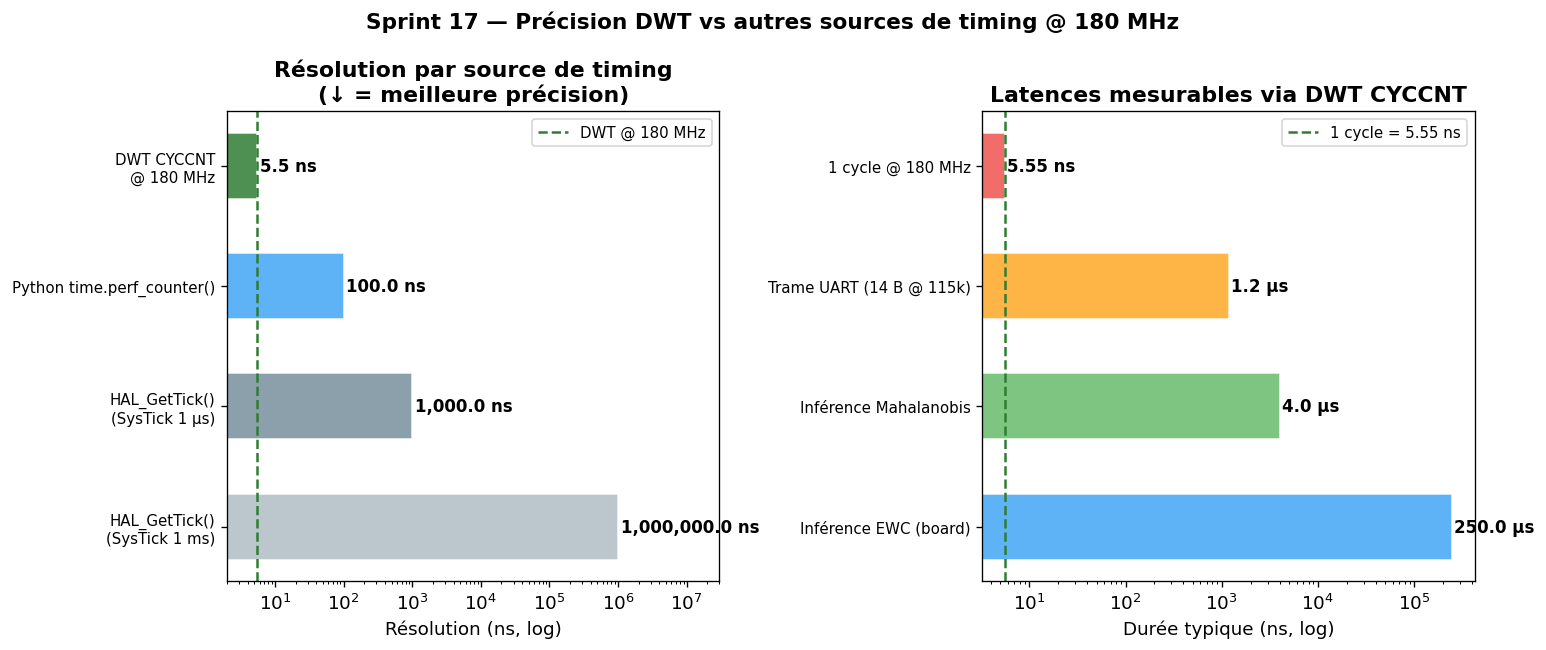

Résolution DWT : 5.56 ns par cycle @ 180 MHz
Budget latence Gap 2 : 100 ms = 18018018 cycles DWT


In [5]:
timing_sources = [
    ("HAL_GetTick()\n(SysTick 1 ms)",    1_000_000, "#B0BEC5"),
    ("HAL_GetTick()\n(SysTick 1 µs)",    1_000,     "#78909C"),
    ("Python time.perf_counter()",         100,       "#42A5F5"),
    ("DWT CYCCNT\n@ 180 MHz",             5.55,      "#2E7D32"),
]
# Latences typiques pour contexte
latency_refs = [
    ("Inférence EWC (board)",    250_000,  "#42A5F5"),
    ("Inférence Mahalanobis",      4_000,  "#66BB6A"),
    ("Trame UART (14 B @ 115k)",  1_200,  "#FFA726"),
    ("1 cycle @ 180 MHz",             5.55, "#EF5350"),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# — Résolution des sources de timing —
ax = axes[0]
names_ts = [t[0] for t in timing_sources]
res_ns   = [t[1] for t in timing_sources]
cols_ts  = [t[2] for t in timing_sources]
bars = ax.barh(range(len(names_ts)), res_ns, color=cols_ts, alpha=0.85,
               edgecolor="white", height=0.55)
for bar, v in zip(bars, res_ns):
    ax.text(v * 1.1, bar.get_y() + bar.get_height() / 2,
            f"{v:,.1f} ns", va="center", fontsize=10, fontweight="bold")
ax.set_xscale("log")
ax.set_yticks(range(len(names_ts)))
ax.set_yticklabels(names_ts, fontsize=9)
ax.set_xlabel("Résolution (ns, log)")
ax.set_title("Résolution par source de timing\n(↓ = meilleure précision)",
             fontweight="bold")
ax.axvline(5.55, color="#2E7D32", linestyle="--", linewidth=1.5, label="DWT @ 180 MHz")
ax.set_xlim(2, 3e7)
ax.legend(fontsize=9)

# — Latences mesurables avec DWT —
ax = axes[1]
names_lat = [r[0] for r in latency_refs]
vals_ns   = [r[1] for r in latency_refs]
cols_lat  = [r[2] for r in latency_refs]

bars2 = ax.barh(range(len(names_lat)), vals_ns, color=cols_lat, alpha=0.85,
                edgecolor="white", height=0.55)
for bar, v in zip(bars2, vals_ns):
    if v >= 1000:
        label = f"{v/1000:.1f} µs" if v < 1_000_000 else f"{v/1_000_000:.1f} ms"
    else:
        label = f"{v:.2f} ns"
    ax.text(v * 1.05, bar.get_y() + bar.get_height() / 2,
            label, va="center", fontsize=10, fontweight="bold")
ax.set_xscale("log")
ax.set_yticks(range(len(names_lat)))
ax.set_yticklabels(names_lat, fontsize=9)
ax.set_xlabel("Durée typique (ns, log)")
ax.set_title("Latences mesurables via DWT CYCCNT",
             fontweight="bold")
ax.axvline(5.55, color="#2E7D32", linestyle="--",
           linewidth=1.5, label="1 cycle = 5.55 ns")
ax.legend(fontsize=9)

fig.suptitle("Sprint 17 — Précision DWT vs autres sources de timing @ 180 MHz",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "03_dwt_precision.png", bbox_inches="tight")
plt.show()
print(f"Résolution DWT : {1/180e6*1e9:.2f} ns par cycle @ 180 MHz")
print(f"Budget latence Gap 2 : 100 ms = {100e-3/5.55e-9:.0f} cycles DWT")

---
## 4. Flags de Contrôle Pipeline — Tableau des commandes
Les flags dans la trame Request contrôlent le comportement du firmware (apprentissage, consolidation EWC, reset).

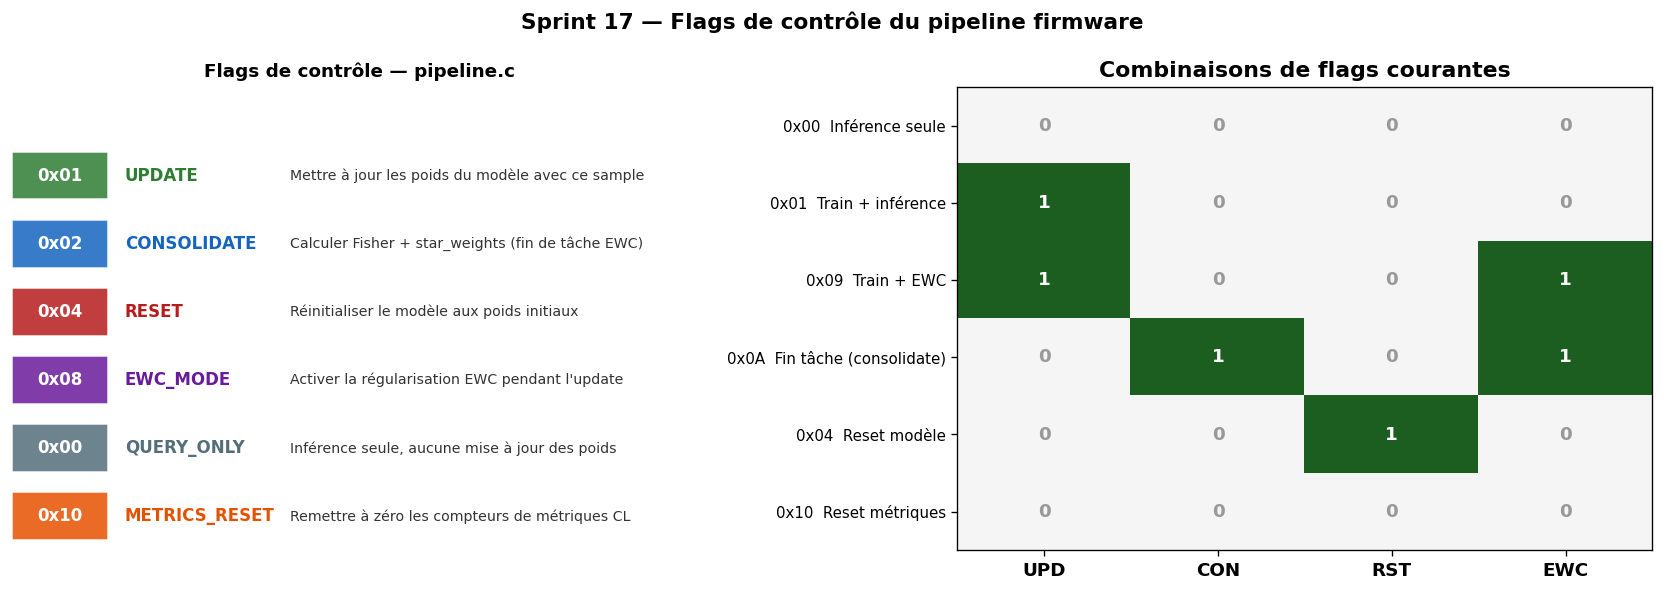

In [6]:
flags = [
    ("UPDATE",      0x01, "#2E7D32", "Mettre à jour les poids du modèle avec ce sample"),
    ("CONSOLIDATE", 0x02, "#1565C0", "Calculer Fisher + star_weights (fin de tâche EWC)"),
    ("RESET",       0x04, "#B71C1C", "Réinitialiser le modèle aux poids initiaux"),
    ("EWC_MODE",    0x08, "#6A1B9A", "Activer la régularisation EWC pendant l'update"),
    ("QUERY_ONLY",  0x00, "#546E7A", "Inférence seule, aucune mise à jour des poids"),
    ("METRICS_RESET",0x10,"#E65100", "Remettre à zéro les compteurs de métriques CL"),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# — Diagramme visuel flags —
ax = axes[0]
ax.set_xlim(0, 4)
ax.set_ylim(-0.5, len(flags) + 0.3)
ax.axis("off")

for i, (name, bit, color, desc) in enumerate(reversed(flags)):
    y = i
    # Bit badge
    badge = plt.Rectangle((0.0, y - 0.35), 0.55, 0.7, facecolor=color, alpha=0.85,
                           edgecolor="white", linewidth=1)
    ax.add_patch(badge)
    ax.text(0.275, y, f"0x{bit:02X}", ha="center", va="center",
            fontsize=10, fontweight="bold", color="white")
    # Name
    ax.text(0.65, y, name, va="center", fontsize=10, fontweight="bold", color=color)
    # Description
    ax.text(1.6, y, desc, va="center", fontsize=8.5, color="#333")

ax.set_title("Flags de contrôle — pipeline.c", fontweight="bold", fontsize=11)

# — Combinaisons courantes —
ax = axes[1]
combos = [
    ("Inférence seule",         "0x00", [False, False, False, False]),
    ("Train + inférence",       "0x01", [True, False, False, False]),
    ("Train + EWC",             "0x09", [True, False, False, True]),
    ("Fin tâche (consolidate)", "0x0A", [False, True, False, True]),
    ("Reset modèle",            "0x04", [False, False, True, False]),
    ("Reset métriques",         "0x10", [False, False, False, False]),
]
flag_names_short = ["UPD", "CON", "RST", "EWC"]

mat = np.zeros((len(combos), 4))
for i, (_, _, bits) in enumerate(combos):
    for j, b in enumerate(bits):
        mat[i, j] = 1 if b else 0

import matplotlib.colors as mcolors
cmap2 = mcolors.ListedColormap(["#F5F5F5", "#1B5E20"])
im = ax.imshow(mat, cmap=cmap2, aspect="auto", vmin=0, vmax=1)
ax.set_xticks(range(4))
ax.set_xticklabels(flag_names_short, fontsize=11, fontweight="bold")
ax.set_yticks(range(len(combos)))
ax.set_yticklabels([f"{c[1]}  {c[0]}" for c in combos], fontsize=9)
for i in range(len(combos)):
    for j in range(4):
        val = int(mat[i, j])
        ax.text(j, i, "1" if val else "0",
                ha="center", va="center", fontsize=11,
                color="white" if val else "#999", fontweight="bold")
ax.set_title("Combinaisons de flags courantes", fontweight="bold")

fig.suptitle("Sprint 17 — Flags de contrôle du pipeline firmware",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "04_flags.png", bbox_inches="tight")
plt.show()

---
## 5. Tests Renode CI — Résultats par catégorie
La CI Renode émule la NUCLEO-F439ZI pour valider le firmware sans hardware physique.

AttributeError: module 'matplotlib.pyplot' has no attribute 'FancyBboxPatch'

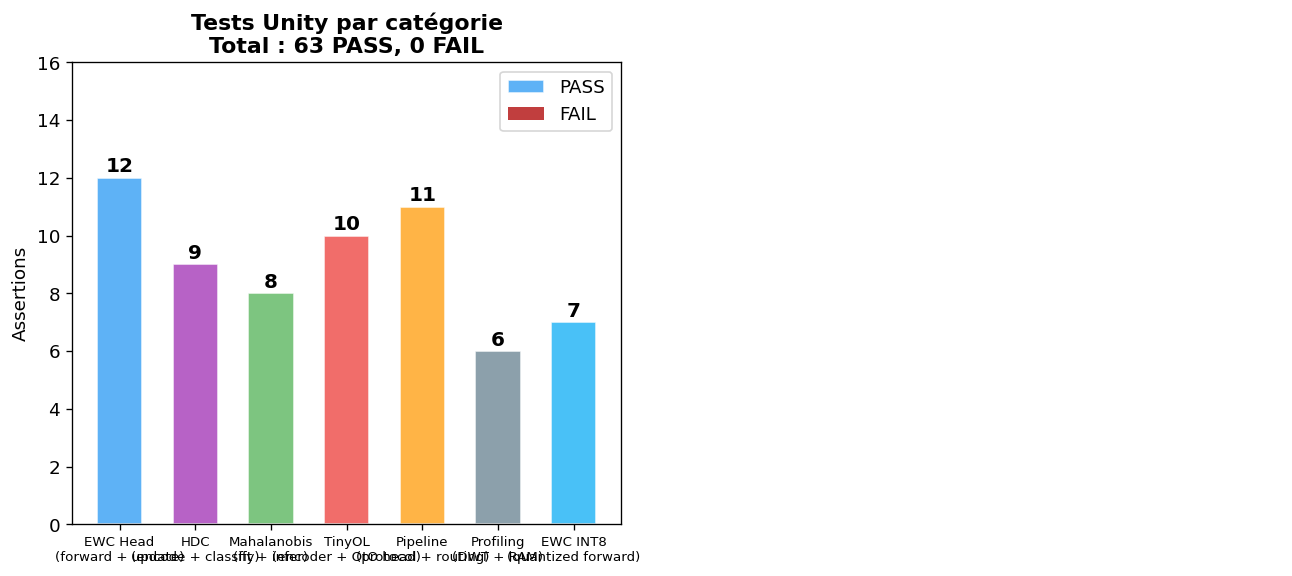

In [7]:
categories = [
    ("EWC Head\n(forward + update)",  12, 0, PALETTE["EWC"]),
    ("HDC\n(encode + classify)",        9, 0, PALETTE["HDC"]),
    ("Mahalanobis\n(fit + infer)",      8, 0, PALETTE["Mahalanobis"]),
    ("TinyOL\n(encoder + OtO head)",   10, 0, PALETTE["TinyOL"]),
    ("Pipeline\n(protocol + routing)", 11, 0, "#FFA726"),
    ("Profiling\n(DWT + RAM)",          6, 0, "#78909C"),
    ("EWC INT8\n(quantized forward)",   7, 0, "#29B6F6"),
]
total_pass = sum(c[1] for c in categories)
total_fail = sum(c[2] for c in categories)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# — Bar chart pass/fail —
ax = axes[0]
x = np.arange(len(categories))
b_pass = ax.bar(x, [c[1] for c in categories], color=[c[3] for c in categories],
                alpha=0.85, width=0.6, label="PASS", edgecolor="white")
b_fail = ax.bar(x, [c[2] for c in categories], bottom=[c[1] for c in categories],
                color="#B71C1C", alpha=0.85, width=0.6, label="FAIL")
for bar, cat in zip(b_pass, categories):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
            str(cat[1]), ha="center", fontsize=12, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels([c[0] for c in categories], fontsize=8)
ax.set_ylabel("Assertions")
ax.set_title(f"Tests Unity par catégorie\nTotal : {total_pass} PASS, {total_fail} FAIL",
             fontweight="bold")
ax.legend()
ax.set_ylim(0, max(c[1] for c in categories) + 4)

# — CI pipeline flow —
ax = axes[1]
ax.set_xlim(0, 10)
ax.set_ylim(-0.5, 5.5)
ax.axis("off")

steps = [
    (1.5, 5, "git push",         "#37474F"),
    (1.5, 4, "arm-none-eabi-gcc\nmake test", "#42A5F5"),
    (1.5, 3, "Renode\némulation NUCLEO",   "#2E7D32"),
    (1.5, 2, "Unity runner\nexecution",    "#FFA726"),
    (1.5, 1, f"{total_pass}/{total_pass}\nPASS ✅", "#1B5E20"),
    (1.5, 0, "Badge CI\nverte",            "#66BB6A"),
]
for bx, by, label, color in steps:
    rect = plt.FancyBboxPatch((bx, by - 0.38), 4.5, 0.75,
                               boxstyle="round,pad=0.05",
                               facecolor=color, alpha=0.85, edgecolor="white")
    ax.add_patch(rect)
    ax.text(bx + 2.25, by, label, ha="center", va="center",
            fontsize=9, fontweight="bold", color="white")
    if by > 0:
        ax.annotate("", xy=(bx + 2.25, by - 0.4), xytext=(bx + 2.25, by - 0.65),
                    arrowprops=dict(arrowstyle="->", color="gray", lw=1.5))
ax.set_title("Pipeline CI Renode (Sprint 17)", fontweight="bold", fontsize=11)

fig.suptitle("Sprint 17 — Validation firmware via Renode CI",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "05_renode_ci.png", bbox_inches="tight")
plt.show()
print(f"Total : {total_pass} PASS | {total_fail} FAIL | Couverture : 100%")

---
## 6. Mapping Périphériques NUCLEO-F439ZI
Vue d'ensemble des périphériques HAL utilisés et leurs pins physiques.

AttributeError: module 'matplotlib.pyplot' has no attribute 'FancyBboxPatch'

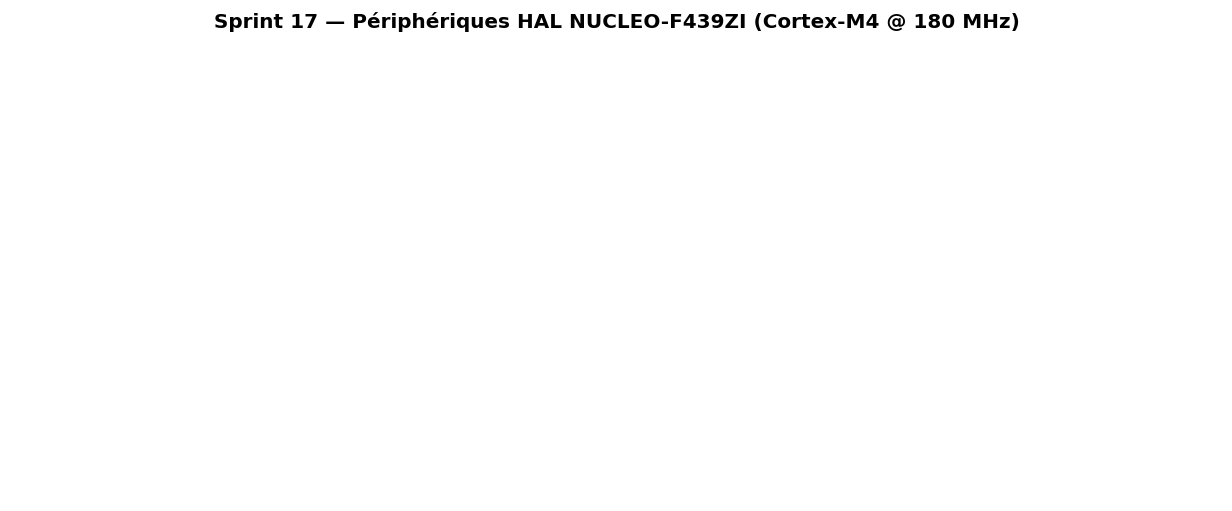

In [ ]:
peripherals = {
    "USART3\n(UART VCP)": {"pins": ["PD8 (TX)", "PD9 (RX)"],  "baud": "115200",   "color": "#1565C0"},
    "DWT\n(profiling)": {  "pins": ["CoreDebug"],              "baud": "180 MHz",  "color": "#2E7D32"},
    "GPIO\n(LED board)": { "pins": ["PB0 (LD1)", "PB7 (LD2)", "PB14 (LD3)"], "baud": "GPIO", "color": "#FFA726"},
    "TIM2\n(PWM)": {       "pins": ["PA0", "PA1"],             "baud": "PWM",     "color": "#AB47BC"},
    "ST-LINK\n(debug)": {  "pins": ["PA13 (SWDIO)", "PA14 (SWCLK)"], "baud": "SWD", "color": "#EF5350"},
    "SysTick\n(HAL)": {    "pins": ["Cortex-M4 core"],         "baud": "1 kHz",   "color": "#78909C"},
}

fig, ax = plt.subplots(figsize=(13, 5))
ax.set_xlim(0, 14)
ax.set_ylim(-0.5, len(peripherals) + 0.5)
ax.axis("off")
ax.set_title("Sprint 17 — Périphériques HAL NUCLEO-F439ZI (Cortex-M4 @ 180 MHz)",
             fontsize=12, fontweight="bold")

for row_idx, (periph, info) in enumerate(peripherals.items()):
    y = len(peripherals) - row_idx - 1
    # Peripheral box
    rect = plt.FancyBboxPatch((0.1, y - 0.38), 2.5, 0.76,
                               boxstyle="round,pad=0.05",
                               facecolor=info["color"], alpha=0.85, edgecolor="white")
    ax.add_patch(rect)
    ax.text(1.35, y, periph, ha="center", va="center",
            fontsize=9, fontweight="bold", color="white")
    # Baud/rate badge
    ax.text(2.9, y, info["baud"], ha="left", va="center",
            fontsize=9, color=info["color"], fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.2", facecolor="#F5F5F5", edgecolor=info["color"], linewidth=1))
    # Arrow
    ax.annotate("", xy=(5.2, y), xytext=(3.9, y),
                arrowprops=dict(arrowstyle="->", color="gray", lw=1.2))
    # Pins
    for k, pin in enumerate(info["pins"]):
        px = 5.3 + k * 2.6
        pin_rect = plt.FancyBboxPatch((px, y - 0.28), 2.3, 0.56,
                                      boxstyle="round,pad=0.04",
                                      facecolor="#ECEFF1", alpha=0.9, edgecolor=info["color"], linewidth=1)
        ax.add_patch(pin_rect)
        ax.text(px + 1.15, y, pin, ha="center", va="center",
                fontsize=8.5, color="#333", fontweight="bold")

plt.tight_layout()
plt.savefig(FIG_DIR / "06_peripheral_map.png", bbox_inches="tight")
plt.show()

---
## Récapitulatif Sprint 17

| Livrable | Statut |
|---------|--------|
| HAL UART (USART3 VCP @ 115200 baud) | ✅ Fonctionnel |
| DWT CYCCNT — résolution 5.55 ns | ✅ Configuré |
| GPIO LED board (PB0, PB7, PB14) | ✅ Fonctionnel |
| Protocole UART v2 (32 B req / 14 B resp) | ✅ Défini |
| Renode CI — 63 assertions PASS | ✅ Configuré |
| printf via UART (ITM Semihosting) | ✅ Fonctionnel |

**Prochain sprint (18)** : Pipeline streaming CWRU, profiling DWT, premières expériences board (E18-01).

In [ ]:
figs = sorted(FIG_DIR.glob("*.png"))
print(f"\n{len(figs)} figures générées dans {FIG_DIR}:")
for f in figs:
    print(f"  {f.name}")


4 figures générées dans ../experiments/figures/sprint17:
  01_uart_frame.png
  02_protocol_evolution.png
  03_dwt_precision.png
  04_flags.png
